# Анализ пространственно-временной динамики ареала лебедей в Северной Америке

---

## Тема проекта

**Анализ пространственно-временной динамики ареала лебедей в Северной Америке.**

---

## Цель проекта

Определить, наблюдается ли статистически значимое смещение ареала лебедей в Северной Америке, и выявить, различается ли это смещение в разных географических зонах. Оценить влияние внешних факторов (температура, плотность населения) на пространственное распределение птиц.

---

## Задачи проекта

1. Загрузить и очистить данные о наблюдениях за лебедями.
2. Добавить внешние данные (плотность населения и температура по штатам и провинциям).
3. Провести кластерный анализ для выделения географических зон.
4. Учесть сезонность и другие искажающие факторы.
5. Провести статистический анализ: оценить тренды, сравнить виды и сезоны.
6. Построить визуализации (не менее 4 графиков).
7. Сформулировать выводы.

---

# Описание датасетов

---

## 1. `short.csv` — наблюдения за лебедями

**Источник:** GBIF (Global Biodiversity Information Facility)

**Объём:** ~3.5 млн записей

| Столбец | Тип | Описание |
|---------|-----|----------|
| `gbifID` | int | Уникальный идентификатор наблюдения |
| `basisOfRecord` | str | Тип записи |
| `recordedBy` | str | Наблюдатель |
| `eventDate` | str | Дата наблюдения |
| `year` | int | Год |
| `month` | int | Месяц |
| `day` | int | День |
| `countryCode` | str | Код страны |
| `stateProvince` | str | Штат / провинция |
| `locality` | str | Локация |
| `decimalLatitude` | float | Широта |
| `decimalLongitude` | float | Долгота |
| `coordinateUncertaintyInMeters` | float | — |
| `coordinatePrecision` | float | — |
| `infraspecificEpithet` | float | — |
| `taxonRank` | str | Ранг таксона |
| `datasetKey` | str | Идентификатор источника |
| `elevation` | float | — |
| `elevationAccuracy` | float | — |
| `depth` | float | — |
| `depthAccuracy` | float | — |
| `species` | str | Вид |

**Виды в датасете:**
- `Cygnus olor` — лебедь-шипун
- `Cygnus buccinator` — лебедь-трубач
- `Cygnus columbianus` — американский тундровый лебедь
- `Cygnus atratus` — чёрный лебедь
- `Cygnus cygnus` — лебедь-кликун
- `Cygnus melancoryphus` — черношейный лебедь

---

## 2. `US_CA.csv` — плотность населения

**Объём:** 69 записей

| Столбец | Тип | Описание |
|---------|-----|----------|
| `state_province` | str | Название штата / провинции |
| `land_area` | float | Площадь, км² |
| `density_per` | float | Плотность населения, чел/км² |

---

## 3. `us_state_temperatures.csv` — температуры США

**Объём:** ~26 868 записей

| Столбец | Тип | Описание |
|---------|-----|----------|
| `state` | str | Название штата |
| `year` | int | Год |
| `month` | int | Месяц |
| `avg_temp_f` | float | Температура, °F |
| `avg_temp_c` | float | Температура, °C |

---

## 4. `canada_temperatures.csv` — температуры Канады

**Объём:** 6 864 записи

| Столбец | Тип | Описание |
|---------|-----|----------|
| `state_province` | str | Название провинции |
| `year` | int | Год |
| `month` | int | Месяц |
| `avg_temp_c` | float | Температура, °C |

---

# Предобработка

Загрузим необходимые библиотеки:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import StandardScaler
from scipy.stats import linregress

In [2]:
pip install inflection

Note: you may need to restart the kernel to use updated packages.


In [3]:
import inflection

In [4]:
!pip install phik

In [5]:
import phik
from phik import phik_matrix

### Блок 1. Загрузка и первичный осмотр

Загрузим данные из файла `short.csv`

In [6]:
df_short = pd.read_csv('short.csv')

Выгрузим общую информацию и первые строки по датасету.

In [7]:
with pd.option_context('display.max_columns', None):
    display(df_short.head())

,gbifID,basisOfRecord,recordedBy,eventDate,year,month,day,countryCode,stateProvince,locality,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,coordinatePrecision,infraspecificEpithet,taxonRank,datasetKey,elevation,elevationAccuracy,depth,depthAccuracy,species
0,938888072,HUMAN_OBSERVATION,obsr137539,2008-01-19,2008,1,19,US,Massachusetts,Provincetown Harbor--boat ramp on Commercial S...,42.041756,-70.193480,NaN,NaN,NaN,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,NaN,NaN,NaN,NaN,Cygnus olor
1,3511818940,HUMAN_OBSERVATION,obsr902368,2021-01-23,2021,1,23,US,Massachusetts,South Hadley Canal Park,42.222797,-72.608850,NaN,NaN,NaN,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,NaN,NaN,NaN,NaN,Cygnus olor
2,5474067204,HUMAN_OBSERVATION,obsr440493,2024-03-21,2024,3,21,US,New York,Marshlands Conservancy,40.953114,-73.701225,NaN,NaN,NaN,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,NaN,NaN,NaN,NaN,Cygnus olor
3,3264353040,HUMAN_OBSERVATION,obsr305952,2020-05-28,2020,5,28,CA,Ontario,Port Franks private beach (restricted access),43.231647,-81.911110,NaN,NaN,NaN,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,NaN,NaN,NaN,NaN,Cygnus olor
4,3630533474,HUMAN_OBSERVATION,obsr1312860,2021-09-09,2021,9,9,CA,Ontario,Niagara-on-the-Lake--Outlet Collection ponds,43.155900,-79.176960,NaN,NaN,NaN,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,NaN,NaN,NaN,NaN,Cygnus buccinator


In [8]:
print(df_short.info())
print(df_short.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 22 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   gbifID                         int64  
 1   basisOfRecord                  object 
 2   recordedBy                     object 
 3   eventDate                      object 
 4   year                           int64  
 5   month                          int64  
 6   day                            int64  
 7   countryCode                    object 
 8   stateProvince                  object 
 9   locality                       object 
 10  decimalLatitude                float64
 11  decimalLongitude               float64
 12  coordinateUncertaintyInMeters  float64
 13  coordinatePrecision            float64
 14  infraspecificEpithet           float64
 15  taxonRank                      object 
 16  datasetKey                     object 
 17  elevation                      float64
 18  el

In [9]:
print(df_short.isna().sum())

gbifID                                 0
basisOfRecord                          0
recordedBy                             0
eventDate                              0
year                                   0
month                                  0
day                                    0
countryCode                            0
stateProvince                          0
locality                               4
decimalLatitude                        0
decimalLongitude                       0
coordinateUncertaintyInMeters    3489498
coordinatePrecision              3489498
infraspecificEpithet             3489498
taxonRank                              0
datasetKey                             0
elevation                        3489498
elevationAccuracy                3489498
depth                            3489498
depthAccuracy                    3489498
species                                0
dtype: int64


Датасет соотвествует описанию, в семи столбцах информация отстутствует (для оптимизации работы данные столбцы необходимо удалить), в столбце `locality` есть пропуски в количестве 4 штук (менее 0,1% от датасета) - при дальнейшей обработке примим решение о действии с ними. В остальных столбцах пропусков нет. Типы данных по столбцам соответствуют наполнению, за исключением столбца `eventDate` - необходимо столбец привести к типу `datetime`.

### Блок 2. Очистка структуры данных

Удалим столбцы, полностью состоящие из пропусков:

In [10]:
df_short = df_short.dropna(axis=1, how='all').copy()

Удалим столбец `locality` - для дальнейшего анализа не понадобится (в анализе будем использовать географические координаты):

In [11]:
df_short = df_short.drop(columns=['locality']).copy()

Приведем названия столбцов к формату `snake_case`:

In [12]:
df_short.columns = df_short.columns.map(inflection.underscore)

In [13]:
print(df_short.columns.tolist())

['gbif_id', 'basis_of_record', 'recorded_by', 'event_date', 'year', 'month', 'day', 'country_code', 'state_province', 'decimal_latitude', 'decimal_longitude', 'taxon_rank', 'dataset_key', 'species']


Преобразуем столбец `event_date` в формат `datetime`:

In [14]:
df_short['event_date'] = pd.to_datetime(df_short['event_date'])

Выведем информацию о датафрейме после проведенной очистки:

In [15]:
print(df_short.info())
print(df_short.shape)
print(df_short.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 14 columns):
 #   Column             Dtype         
---  ------             -----         
 0   gbif_id            int64         
 1   basis_of_record    object        
 2   recorded_by        object        
 3   event_date         datetime64[ns]
 4   year               int64         
 5   month              int64         
 6   day                int64         
 7   country_code       object        
 8   state_province     object        
 9   decimal_latitude   float64       
 10  decimal_longitude  float64       
 11  taxon_rank         object        
 12  dataset_key        object        
 13  species            object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(7)
memory usage: 372.7+ MB
None
(3489498, 14)
gbif_id              0
basis_of_record      0
recorded_by          0
event_date           0
year                 0
month                0
day                  0


Очистка произведена корректно, пропусков нет, количество строк соответствует первоначальному, количество столбцов соответствует разнице на удаленные колонки. Данные с датой и временем отражены корректно.

### Блок 3. Фильтрация данных

Отфильтруем датасет по трем видам лебедей (`Cygnus olor`, `Cygnus buccinator`, `Cygnus columbianus`) и по территории наблюдения США и Канады.

In [16]:
print('Виды лебедей:')
print(df_short['species'].unique())
print()
print('Страна наблюдения:')
print(df_short['country_code'].unique())

Виды лебедей:
['Cygnus olor' 'Cygnus buccinator' 'Cygnus columbianus' 'Cygnus cygnus'
 'Cygnus atratus' 'Cygnus melancoryphus']

Страна наблюдения:
['US' 'CA' 'MX' 'BM' 'DO' 'PR' 'VI' 'BS' 'GL']


Фильтруем по видам лебедей:

In [17]:
df_short = df_short.loc[(df_short['species']=='Cygnus olor')|(df_short['species']=='Cygnus buccinator')|(df_short['species']=='Cygnus columbianus')].copy()

Фильтруем по странам:

In [18]:
df_short = df_short.loc[(df_short['country_code']=='US')|(df_short['country_code']=='CA')].copy()

Проверим координаты вошедшие в датасет:

In [19]:
print('Широта (диапозон):')
print(df_short['decimal_latitude'].min()), print(df_short['decimal_latitude'].max())
print()
print('Долгота (диапозон):')
print(df_short['decimal_longitude'].min()), print(df_short['decimal_longitude'].max())

Широта (диапозон):
25.253895
74.2833

Долгота (диапозон):
-176.64543
178.36043


(None, None)

Ограничим координаты данными: широта 25–75°, долгота −170…−35°. По широте корректировка не требуется, по долготе произведем фильтрацию:

In [20]:
df_short = df_short.loc[(df_short['decimal_longitude']>=-170)&(df_short['decimal_longitude']<=-35)].copy()

In [21]:
print('Долгота (диапозон):')
print(df_short['decimal_longitude'].min()), print(df_short['decimal_longitude'].max())

Долгота (диапозон):
-169.60693
-52.694126


(None, None)

Проверим наличие избыточных столбцов (содержащих только одно уникальное значение):

In [22]:
for column in df_short.columns:
    print(f'Уникальные значения в столбце {column}:')
    print(df_short[column].sort_values().nunique())
    print()

Уникальные значения в столбце gbif_id:
3477414

Уникальные значения в столбце basis_of_record:
1

Уникальные значения в столбце recorded_by:
133457

Уникальные значения в столбце event_date:
16041

Уникальные значения в столбце year:
45

Уникальные значения в столбце month:
12

Уникальные значения в столбце day:
31

Уникальные значения в столбце country_code:
2

Уникальные значения в столбце state_province:
62

Уникальные значения в столбце decimal_latitude:
326558

Уникальные значения в столбце decimal_longitude:
331078

Уникальные значения в столбце taxon_rank:
1

Уникальные значения в столбце dataset_key:
1

Уникальные значения в столбце species:
3



Избыточные столбцы, содержащие только одно значение это - `basis_of_record`, `taxon_rank`, `dataset_key`. Удалим эти столбцы:

In [23]:
df_short = df_short.drop(columns=['basis_of_record', 'taxon_rank', 'dataset_key']).copy()

Для анализа необходимы данные только по 2023 год включительно. Проверим какие периоды присутствуют в датасете и удалим лишние:

In [24]:
print(df_short['year'].sort_values().unique())

[1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022 2023 2024]


Отфильтруем датасет и удалим данные за 2024 год:

In [25]:
df_short = df_short.loc[~(df_short['year']==2024)].copy()

Выведем данные по отфильтрованному датасету:

In [26]:
print(df_short.info())
print(df_short.shape)
print(df_short.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3033096 entries, 0 to 3489497
Data columns (total 11 columns):
 #   Column             Dtype         
---  ------             -----         
 0   gbif_id            int64         
 1   recorded_by        object        
 2   event_date         datetime64[ns]
 3   year               int64         
 4   month              int64         
 5   day                int64         
 6   country_code       object        
 7   state_province     object        
 8   decimal_latitude   float64       
 9   decimal_longitude  float64       
 10  species            object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 277.7+ MB
None
(3033096, 11)
gbif_id              0
recorded_by          0
event_date           0
year                 0
month                0
day                  0
country_code         0
state_province       0
decimal_latitude     0
decimal_longitude    0
species              0
dtype: int64


Датасет подготовлен к дальнейшей работе, необходимые фильтрации произведены. Итоговых записей осталось `3033096` (данные включают два региона и три вида лебедей в период по 2023 год включительно.)

### Блок 4. Обогащение данными

Загрузим данные файла `US_CA.csv`.

In [27]:
df_us_ca = pd.read_csv('US_CA.csv')

In [28]:
display(df_us_ca.head())

,state_province,land_area,density_per
0,District of Columbia,158.0,4297.0
1,New Jersey,19047.0,488.0
2,Rhode Island,2678.0,409.0
3,Puerto Rico,8868.0,361.0
4,Massachusetts,20202.0,347.0


In [29]:
print(df_us_ca.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   state_province  69 non-null     object 
 1   land_area       69 non-null     float64
 2   density_per     69 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.7+ KB
None


В датасете нет пропусков, данные соответствуют описанию.

Определим уникальное количество записей в данных `US_CA.csv`:

In [30]:
print(df_us_ca['state_province'].nunique())

69


Определим уникальное количество записей по столбцу `state_province` в данных датасета `df_short`: 

In [31]:
print(df_short['state_province'].nunique())

62


Выведем названия штатов из двух датасетов:

In [32]:
print(df_us_ca['state_province'].sort_values().tolist())

['AB', 'Alabama', 'Alaska', 'American Samoa[4]', 'Arizona', 'Arkansas', 'British Columbia', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Guam[4]', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Manitoba', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Brunswick', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'Newfoundland and Labrador', 'North Carolina', 'North Dakota', 'Northern Mariana Islands[4]', 'Northwest Territories', 'Nova Scotia', 'Nunavut', 'Ohio', 'Oklahoma', 'Ontario', 'Oregon', 'Pennsylvania', 'Prince Edward Island', 'Puerto Rico', 'Quebec', 'Rhode Island', 'Saskatchewan', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'U.S. Virgin Islands[4]', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming', 'Yukon']


In [33]:
print(df_short['state_province'].sort_values().unique().tolist())

['Alabama', 'Alaska', 'Alberta', 'Arizona', 'Arkansas', 'British Columbia', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Manitoba', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Brunswick', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'Newfoundland and Labrador', 'North Carolina', 'North Dakota', 'Northwest Territories', 'Nova Scotia', 'Nunavut', 'Ohio', 'Oklahoma', 'Ontario', 'Oregon', 'Pennsylvania', 'Quebec', 'Rhode Island', 'Saskatchewan', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming', 'Yukon Territory']


Наблюдаем, что названия штатов не идентичны. Определим какие штаты из таблицы `US_CA.csv` необходимо заменить и скорректируем названия:

In [34]:
state_province_us_ca = df_us_ca['state_province'].sort_values().tolist() #сохраним список штатов датасета `df_us_ca`
print(df_short['state_province'].loc[(~df_short['state_province'].isin(state_province_us_ca))].unique()) #определим штаты для корректировки

['Yukon Territory' 'Alberta']


Заменим наименования штатов `Yukon, AB` на `Yukon Territory, Alberta` в датасете df_us_ca: 

In [35]:
df_us_ca['state_province'] = df_us_ca['state_province'].str.replace('Yukon', 'Yukon Territory')
df_us_ca['state_province'] = df_us_ca['state_province'].str.replace('AB', 'Alberta')

Проверим корректность замены:

In [36]:
state_province_us_ca = df_us_ca['state_province'].sort_values().tolist() #сохраним список штатов датасета `df_us_ca`
print(df_short['state_province'].loc[(~df_short['state_province'].isin(state_province_us_ca))].unique()) #определим штаты для корректировки

[]


Наименования штатов в обоих датасетах приведены к одному виду. Объединим датасеты:

In [37]:
df = pd.merge(df_short, df_us_ca, how='left', on='state_province')

In [38]:
display(df.head())

,gbif_id,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,species,land_area,density_per
0,938888072,obsr137539,2008-01-19,2008,1,19,US,Massachusetts,42.041756,-70.19348,Cygnus olor,20202.00,347.00
1,3511818940,obsr902368,2021-01-23,2021,1,23,US,Massachusetts,42.222797,-72.60885,Cygnus olor,20202.00,347.00
2,3264353040,obsr305952,2020-05-28,2020,5,28,CA,Ontario,43.231647,-81.91111,Cygnus olor,1076395.00,15.20
3,3630533474,obsr1312860,2021-09-09,2021,9,9,CA,Ontario,43.155900,-79.17696,Cygnus buccinator,1076395.00,15.20
4,3244141543,obsr58975,2020-05-29,2020,5,29,CA,Yukon Territory,60.424446,-134.24268,Cygnus buccinator,474712.68,0.08


In [39]:
print(df.info())
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3033096 entries, 0 to 3033095
Data columns (total 13 columns):
 #   Column             Dtype         
---  ------             -----         
 0   gbif_id            int64         
 1   recorded_by        object        
 2   event_date         datetime64[ns]
 3   year               int64         
 4   month              int64         
 5   day                int64         
 6   country_code       object        
 7   state_province     object        
 8   decimal_latitude   float64       
 9   decimal_longitude  float64       
 10  species            object        
 11  land_area          float64       
 12  density_per        float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(4)
memory usage: 324.0+ MB
None
gbif_id              0
recorded_by          0
event_date           0
year                 0
month                0
day                  0
country_code         0
state_province       0
decimal_latitude     0
decimal

После объединения датасетов количество строк не изменилось, пропусков нет. 

Загрузим данные с температурой:

In [40]:
df_us_t = pd.read_csv('us_state_temperatures.csv')
df_can_t = pd.read_csv('canada_temperatures.csv')

Выведем первые строки датасетов:

In [41]:
display(df_us_t.head())
display(df_can_t.head())

,state,year,month,avg_temp_f,avg_temp_c
0,Alabama,1980,1,46.7,8.166667
1,Alabama,1980,2,42.7,5.944444
2,Alabama,1980,3,52.6,11.444444
3,Alabama,1980,4,60.6,15.888889
4,Alabama,1980,5,70.2,21.222222


,state_province,year,month,avg_temp_c
0,Alberta,1980,1,-15.833060
1,Alberta,1980,2,-8.911123
2,Alberta,1980,3,-6.203974
3,Alberta,1980,4,7.940524
4,Alberta,1980,5,11.229850


Приведем таблицы к единому формату - удалим столбец `avg_temp_f` из датафрейма `df_us_t` и переименуем столбец `state` в `state_province`:

In [42]:
df_us_t = df_us_t.drop(columns=['avg_temp_f']).copy()

In [43]:
df_us_t = df_us_t.rename(columns={'state':'state_province'})

Выведем информацию по датафреймам с температурой:

In [44]:
print(df_us_t.info())
print(df_can_t.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26868 entries, 0 to 26867
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   state_province  26868 non-null  object 
 1   year            26868 non-null  int64  
 2   month           26868 non-null  int64  
 3   avg_temp_c      26868 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 839.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6864 entries, 0 to 6863
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   state_province  6864 non-null   object 
 1   year            6864 non-null   int64  
 2   month           6864 non-null   int64  
 3   avg_temp_c      6864 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 214.6+ KB
None


Тип данных и названия колонок совпадают, объединим датафреймы в один:

In [45]:
temperatures_US_CA = pd.concat([df_us_t, df_can_t], ignore_index=True)

In [46]:
print(temperatures_US_CA.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33732 entries, 0 to 33731
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   state_province  33732 non-null  object 
 1   year            33732 non-null  int64  
 2   month           33732 non-null  int64  
 3   avg_temp_c      33732 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 1.0+ MB
None


Количество строк соответствует сумме двух датафреймов, тип данных корректен. Проверим уникальность пар `(state_province, year, month)`:

In [47]:
display(temperatures_US_CA[temperatures_US_CA.duplicated(subset=['state_province', 'year', 'month'], keep=False)])

,state_province,year,month,avg_temp_c


Дубликатов в датафрейме нет, данные корректны.

### Блок 5. Сезонная фильтрация

Оставим в датафрейме `df` только месяцы:\
    - **Зимовка:** декабрь, январь, февраль\
    - **Гнездование:** июнь, июль, август

In [48]:
print(sorted(df['month'].unique().tolist()))#выведем наименования месяцев в столбце

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [49]:
df=df.loc[(df['month']==12)|(df['month']==1)|(df['month']==2)|(df['month']==6)|(df['month']==7)|(df['month']==8)].copy()

In [50]:
print(sorted(df['month'].unique().tolist()))#выведем наименования месяцев в столбце

[1, 2, 6, 7, 8, 12]


Создадим дополнительный столбец `period_type`:\
    - `1` для зимовки \
    - `2` для гнездования

In [51]:
df['period_type'] = 1
df.loc[df['month'].isin([6,7,8]), 'period_type'] = 2

In [52]:
display(df.tail())

,gbif_id,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,species,land_area,density_per,period_type
3033087,976313833,obsr195212,2013-12-29,2013,12,29,US,Pennsylvania,42.158680,-80.099460,Cygnus olor,115883.0,112.0,1
3033088,1711521237,obsr232297,2016-01-23,2016,1,23,US,Michigan,42.592648,-82.771515,Cygnus olor,146435.0,69.0,1
3033089,1750598501,obsr437792,2016-07-11,2016,7,11,US,New Jersey,39.465000,-74.447780,Cygnus olor,19047.0,488.0,2
3033092,274973516,obsr146576,2010-02-21,2010,2,21,US,Maryland,37.974854,-75.863980,Cygnus columbianus,25142.0,246.0,1
3033094,1201436958,obsr32975,2014-12-31,2014,12,31,US,Vermont,42.784630,-72.519850,Cygnus olor,23871.0,27.0,1


Столбец добавлен корректно.

### Блок 6. Временная разбивка

Разделим данные на 5 временных периодов:\
    - `1_1980-1988`\
    - `2_1989-1997`\
    - `3_1998-2006`\
    - `4_2007-2015`\
    - `5_2016-2023`\
Создадим столбец `time_period`:

In [53]:
df['time_period'] = pd.cut(df['year'], bins=[1979, 1988, 1997, 2006, 2015, 2023], labels=['1_1980-1988', '2_1989-1997', '3_1998-2006', '4_2007-2015', '5_2016-2023'])

In [54]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1289670 entries, 0 to 3033094
Data columns (total 15 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   gbif_id            1289670 non-null  int64         
 1   recorded_by        1289670 non-null  object        
 2   event_date         1289670 non-null  datetime64[ns]
 3   year               1289670 non-null  int64         
 4   month              1289670 non-null  int64         
 5   day                1289670 non-null  int64         
 6   country_code       1289670 non-null  object        
 7   state_province     1289670 non-null  object        
 8   decimal_latitude   1289670 non-null  float64       
 9   decimal_longitude  1289670 non-null  float64       
 10  species            1289670 non-null  object        
 11  land_area          1289670 non-null  float64       
 12  density_per        1289670 non-null  float64       
 13  period_type        1289670 

Данные категоризированы, пропусков нет.

### Блок 7. Работа с координатами и дубликатами

Округлим данные в столбцах `decimal_latitude` и `decimal_longitude` до целых чисел:

In [55]:
df[['decimal_latitude', 'decimal_longitude']] = df[['decimal_latitude', 'decimal_longitude']].astype('int64')

Удалим дубликаты по набору `(year, period_type, decimal_longitude, decimal_latitude, species)`:

In [56]:
duplicated = df[df.duplicated(subset=['year', 'period_type', 'decimal_longitude', 'decimal_latitude', 'species'], keep=False)]
display(duplicated.sort_values(by='gbif_id'))

,gbif_id,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,species,land_area,density_per,period_type,time_period
1216705,132832261,obsr20028,2000-08-26,2000,8,26,US,Michigan,46,-85,Cygnus buccinator,146435.0,69.0,2,3_1998-2006
822285,132832262,obsr20028,2000-08-27,2000,8,27,US,Michigan,46,-85,Cygnus buccinator,146435.0,69.0,2,3_1998-2006
1359709,132832263,obsr20028,2000-08-28,2000,8,28,US,Michigan,46,-85,Cygnus buccinator,146435.0,69.0,2,3_1998-2006
2879449,132832264,obsr20028,2000-08-30,2000,8,30,US,Michigan,46,-85,Cygnus buccinator,146435.0,69.0,2,3_1998-2006
1096881,132832273,obsr20028,1999-07-29,1999,7,29,US,Michigan,46,-85,Cygnus buccinator,146435.0,69.0,2,3_1998-2006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117926,5716369359,obsr1147720,2020-12-31,2020,12,31,US,California,38,-121,Cygnus columbianus,403466.0,97.0,1,5_2016-2023
3019388,5716374591,obsr135713,2017-08-13,2017,8,13,CA,Ontario,42,-83,Cygnus olor,1076395.0,15.2,2,5_2016-2023
221419,5716375131,obsr848862,2021-01-30,2021,1,30,CA,British Columbia,49,-123,Cygnus buccinator,944735.0,5.4,1,5_2016-2023
2080796,5716375334,obsr512860,2021-02-03,2021,2,3,CA,Ontario,43,-79,Cygnus olor,1076395.0,15.2,1,5_2016-2023


In [57]:
df_clear = df.drop_duplicates(subset=['year', 'period_type', 'decimal_longitude', 'decimal_latitude', 'species'], keep='first').copy()
display(df_clear.head())
print(f'Количество строк после удаления дубликатов: {df_clear.shape[0]}')

,gbif_id,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,species,land_area,density_per,period_type,time_period
0,938888072,obsr137539,2008-01-19,2008,1,19,US,Massachusetts,42,-70,Cygnus olor,20202.0,347.0,1,4_2007-2015
1,3511818940,obsr902368,2021-01-23,2021,1,23,US,Massachusetts,42,-72,Cygnus olor,20202.0,347.0,1,5_2016-2023
5,1708517102,obsr46830,2016-01-03,2016,1,3,US,Michigan,42,-85,Cygnus buccinator,146435.0,69.0,1,5_2016-2023
6,5349334195,obsr6752262,2023-01-19,2023,1,19,US,Virginia,37,-76,Cygnus columbianus,102279.0,85.0,1,5_2016-2023
7,2035949122,obsr379975,2017-01-21,2017,1,21,CA,British Columbia,50,-116,Cygnus buccinator,944735.0,5.4,1,5_2016-2023


Количество строк после удаления дубликатов: 32923


Количество строк сократилось с 1280909 до 32923.

### Блок 8. Объединение с температурой

Объединим датасет `df_clear` с датасетом `temperatures_US_CA` по ключу `(state_province, year, month)`.

Предварительно сопоставим наименования штатов в датасетах:

In [58]:
state_province_t = temperatures_US_CA['state_province'].unique().tolist()
print(sorted(state_province_t))

['Alabama', 'Alaska', 'Alberta', 'Arizona', 'Arkansas', 'British Columbia', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Manitoba', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Brunswick', 'New_Hampshire', 'New_Jersey', 'New_Mexico', 'New_York', 'Newfoundland and Labrador', 'North_Carolina', 'North_Dakota', 'Northwest Territories', 'Nova Scotia', 'Nunavut', 'Ohio', 'Oklahoma', 'Ontario', 'Oregon', 'Pennsylvania', 'Prince Edward Island', 'Quebec', 'Rhode_Island', 'Saskatchewan', 'South_Carolina', 'South_Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West_Virginia', 'Wisconsin', 'Wyoming', 'Yukon Territory']


In [59]:
print(df_clear[~df_clear['state_province'].isin(state_province_t)]['state_province'].unique().tolist())

['North Carolina', 'New Jersey', 'New York', 'South Carolina', 'New Mexico', 'Rhode Island', 'West Virginia', 'North Dakota', 'New Hampshire', 'South Dakota', 'District of Columbia']


В датасете `temperatures_US_CA` отличается написание штатов с двойным названием, приведем к единому стилю:

In [60]:
temperatures_US_CA['state_province'] = temperatures_US_CA['state_province'].str.replace('_', ' ', regex=False)

In [61]:
state_province_cor = temperatures_US_CA['state_province'].unique().tolist()
print(sorted(state_province_cor))

['Alabama', 'Alaska', 'Alberta', 'Arizona', 'Arkansas', 'British Columbia', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Manitoba', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Brunswick', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'Newfoundland and Labrador', 'North Carolina', 'North Dakota', 'Northwest Territories', 'Nova Scotia', 'Nunavut', 'Ohio', 'Oklahoma', 'Ontario', 'Oregon', 'Pennsylvania', 'Prince Edward Island', 'Quebec', 'Rhode Island', 'Saskatchewan', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming', 'Yukon Territory']


In [62]:
print(df_clear[~df_clear['state_province'].isin(state_province_cor)]['state_province'].unique().tolist())

['District of Columbia']


В данных температуры отстутствует один штат, объединим датасеты и проверим пропуски:

In [63]:
data_seasonal_enriched = pd.merge(df_clear, temperatures_US_CA, how='left', on=['state_province', 'year', 'month'])

In [64]:
print(data_seasonal_enriched.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32923 entries, 0 to 32922
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   gbif_id            32923 non-null  int64         
 1   recorded_by        32923 non-null  object        
 2   event_date         32923 non-null  datetime64[ns]
 3   year               32923 non-null  int64         
 4   month              32923 non-null  int64         
 5   day                32923 non-null  int64         
 6   country_code       32923 non-null  object        
 7   state_province     32923 non-null  object        
 8   decimal_latitude   32923 non-null  int64         
 9   decimal_longitude  32923 non-null  int64         
 10  species            32923 non-null  object        
 11  land_area          32923 non-null  float64       
 12  density_per        32923 non-null  float64       
 13  period_type        32923 non-null  int64         
 14  time_p

In [65]:
display(data_seasonal_enriched[data_seasonal_enriched['avg_temp_c'].isna()])

,gbif_id,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,species,land_area,density_per,period_type,time_period,avg_temp_c
4643,1377874158,obsr247156,2015-07-14,2015,7,14,US,District of Columbia,38,-77,Cygnus olor,158.0,4297.0,2,4_2007-2015,NaN
4859,1400540663,obsr18062,2015-12-05,2015,12,5,US,District of Columbia,38,-77,Cygnus olor,158.0,4297.0,1,4_2007-2015,NaN
23306,179600893,obsr131204,1994-12-31,1994,12,31,US,District of Columbia,38,-77,Cygnus columbianus,158.0,4297.0,1,2_1989-1997,NaN
26088,179600890,obsr131204,2002-08-14,2002,8,14,US,District of Columbia,38,-77,Cygnus columbianus,158.0,4297.0,2,3_1998-2006,NaN
27865,148748234,obsr31363,2004-06-17,2004,6,17,US,District of Columbia,38,-77,Cygnus columbianus,158.0,4297.0,2,3_1998-2006,NaN
30129,148748233,obsr31363,2005-07-25,2005,7,25,US,District of Columbia,38,-77,Cygnus columbianus,158.0,4297.0,2,3_1998-2006,NaN


Пропуски температуры присутствуют в данных по штату `District of Columbia`. Заполним пропуски средними данными температуры по связке `(decimal_latitude, decimal_longitude, year, month)`:

In [66]:
data_seasonal_enriched['avg_temp_c'] = data_seasonal_enriched['avg_temp_c'].fillna(
    data_seasonal_enriched.groupby(['decimal_latitude', 'decimal_longitude', 'year', 'month'])['avg_temp_c'].transform('mean'))

In [67]:
display(data_seasonal_enriched[data_seasonal_enriched['avg_temp_c'].isna()])

,gbif_id,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,species,land_area,density_per,period_type,time_period,avg_temp_c
4643,1377874158,obsr247156,2015-07-14,2015,7,14,US,District of Columbia,38,-77,Cygnus olor,158.0,4297.0,2,4_2007-2015,NaN
4859,1400540663,obsr18062,2015-12-05,2015,12,5,US,District of Columbia,38,-77,Cygnus olor,158.0,4297.0,1,4_2007-2015,NaN
23306,179600893,obsr131204,1994-12-31,1994,12,31,US,District of Columbia,38,-77,Cygnus columbianus,158.0,4297.0,1,2_1989-1997,NaN


После заполнения пропусков связкой `(decimal_latitude, decimal_longitude, year, month)` сохраняются пропуски в трех строках, используем для их заполнения всязку  `(decimal_latitude, decimal_longitude, month)`:

In [68]:
data_seasonal_enriched['avg_temp_c'] = data_seasonal_enriched['avg_temp_c'].fillna(
    data_seasonal_enriched.groupby(['decimal_latitude', 'decimal_longitude', 'month'])['avg_temp_c'].transform('mean'))

In [69]:
print(data_seasonal_enriched.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32923 entries, 0 to 32922
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   gbif_id            32923 non-null  int64         
 1   recorded_by        32923 non-null  object        
 2   event_date         32923 non-null  datetime64[ns]
 3   year               32923 non-null  int64         
 4   month              32923 non-null  int64         
 5   day                32923 non-null  int64         
 6   country_code       32923 non-null  object        
 7   state_province     32923 non-null  object        
 8   decimal_latitude   32923 non-null  int64         
 9   decimal_longitude  32923 non-null  int64         
 10  species            32923 non-null  object        
 11  land_area          32923 non-null  float64       
 12  density_per        32923 non-null  float64       
 13  period_type        32923 non-null  int64         
 14  time_p

Пропуски заполнены, количество строк после объединения с температурой не изменилось.

### Блок 9. Сохранение и финальная проверка

Сохраним подготовленный датасет в `data_seasonal_enriched.csv`:

In [70]:
data_seasonal_enriched.to_csv('data_seasonal_enriched.csv', sep=',', index=False)

Выведем общую информацию об итоговом датасете:

In [71]:
print(data_seasonal_enriched.shape)

(32923, 16)


Итоговый файл содержит 32923 записи.

Проверим распределение данных по периодам:

In [72]:
display(pd.pivot_table(data_seasonal_enriched, index='time_period', values='gbif_id', aggfunc='count'))

,gbif_id
time_period,
1_1980-1988,1707
2_1989-1997,2931
3_1998-2006,5265
4_2007-2015,9587
5_2016-2023,13433


Проверим распределение данных по видам:

In [73]:
display(pd.pivot_table(data_seasonal_enriched, index='species', values='gbif_id', aggfunc='count'))

,gbif_id
species,
Cygnus buccinator,11831
Cygnus columbianus,11047
Cygnus olor,10045


Проверим среднюю температуру по сезонам:

In [74]:
display(pd.pivot_table(data_seasonal_enriched, index='period_type', values='avg_temp_c', aggfunc='mean'))

,avg_temp_c
period_type,
1,-0.598002
2,17.466384


Проверим среднюю широту по сезонам:

In [75]:
display(pd.pivot_table(data_seasonal_enriched, index='period_type', values='decimal_latitude', aggfunc='mean'))

,decimal_latitude
period_type,
1,41.194096
2,48.684809


Проверка данных показала, что количество наблюдений с течением времени существенно увеличивается. Распределение по видам в пределах 2000 наблюдений, средняя температура по сезонам соответствует показателям зимы/лета, также наблюдается смещение широты по сезонам, что может говорить о сезонной миграции.

В ходе предобработки данных были удалены пустые столбцы, столбцы с избыточными данными (содержащими только одно значение). Произведена фильтрация по географическим координатам, видам лебедей и сезонам (зимовка/гнездование). Добавлены данные по плотности населения и температуре. Были выделены 5 временных периода (1980-1988, 1989-1997, 1998-2006, 2007-2015, 2016-2023). Данные очищены от дубликатов, пропуски в данных температуры заменены на средние значения по координатам и периодам (месяц, год). Итоговый датафрейм сохранен в `data_seasonal_enriched.csv`. Количество записей сооставляет 32923 строки.

---

# Кластерный анализ

Агрегируем данные по ячейкам (широта + долгота),  стандартизируем координаты, применим метод Уорда, выделим 5 кластеров:

In [76]:
coords = data_seasonal_enriched[['decimal_latitude', 'decimal_longitude']].values
coords_scaled = StandardScaler().fit_transform(coords)

linkage_matrix = linkage(coords_scaled, method='ward')
data_seasonal_enriched['cluster'] = fcluster(linkage_matrix, t=5, criterion='maxclust')

Визуализируем распределение по кластерам, используя диаграмму рессеивания:

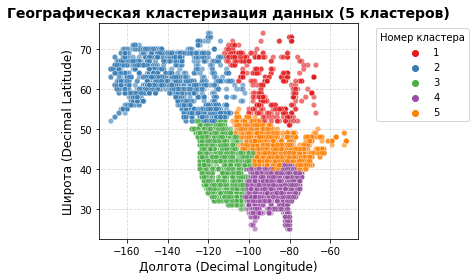

In [77]:
sns.scatterplot(data=data_seasonal_enriched, 
                x='decimal_longitude', 
                y='decimal_latitude', 
                hue='cluster', 
                palette='Set1', 
                alpha=0.6,
                s=30)

plt.title('Географическая кластеризация данных (5 кластеров)', fontsize=14, fontweight='bold')
plt.xlabel('Долгота (Decimal Longitude)', fontsize=12)
plt.ylabel('Широта (Decimal Latitude)', fontsize=12)

plt.legend(title='Номер кластера', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Выведим среднюю широту, температуру и число записей по каждому кластеру:

In [78]:
claster_analysis = data_seasonal_enriched.groupby('cluster').agg({'decimal_latitude':'mean', 'avg_temp_c':'mean', 'gbif_id':'count'}).reset_index()
claster_analysis = claster_analysis.rename(columns={
    'cluster': 'кластер', 
    'decimal_latitude': 'широта', 
    'avg_temp_c': 'средняя температура', 
    'gbif_id': 'количество записей'
})
display(claster_analysis)

,кластер,широта,средняя температура,количество записей
0,1,61.433140,10.869984,688
1,2,61.509215,9.456590,3961
2,3,43.151796,5.173000,8854
3,4,36.908177,7.798073,8059
4,5,43.219435,6.016962,11361


Визуализируем данные с использованием столбчатых диаграмм:

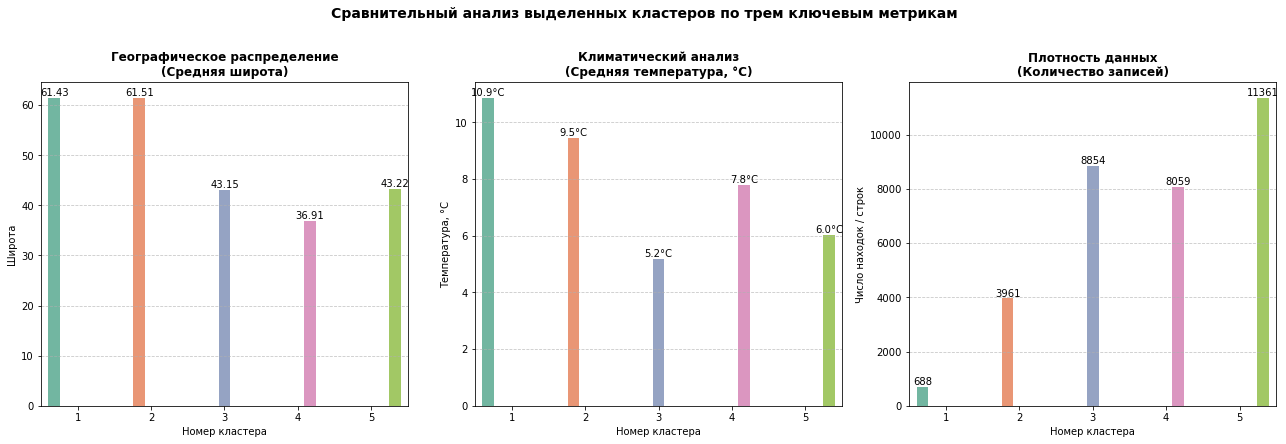

In [79]:
# Делаем номер кластера строкой для дискретных цветов на графике
claster_analysis['кластер'] = claster_analysis['кластер'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = sns.color_palette('Set2', n_colors=5)

# --- ГРАФИК 1: СРЕДНЯЯ ШИРОТА ---
sns.barplot(
    data=claster_analysis, 
    x='кластер', 
    y='широта', 
    ax=axes[0], 
    palette=colors,
    hue='кластер'
)
axes[0].set_title('Географическое распределение\n(Средняя широта)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Номер кластера')
axes[0].set_ylabel('Широта')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
if axes[0].get_legend() is not None: axes[0].get_legend().remove()

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)


# --- ГРАФИК 2: СРЕДНЯЯ ТЕМПЕРАТУРА ---
sns.barplot(
    data=claster_analysis, 
    x='кластер', 
    y='средняя температура', 
    ax=axes[1], 
    palette=colors,
    hue='кластер'
)
axes[1].set_title('Климатический анализ\n(Средняя температура, °C)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Номер кластера')
axes[1].set_ylabel('Температура, °C')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
if axes[1].get_legend() is not None: axes[1].get_legend().remove()

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}°C", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)


# --- ГРАФИК 3: КОЛИЧЕСТВО НАБЛЮДЕНИЙ ---
sns.barplot(
    data=claster_analysis, 
    x='кластер', 
    y='количество записей', 
    ax=axes[2], 
    palette=colors,
    hue='кластер'
)
axes[2].set_title('Плотность данных\n(Количество записей)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Номер кластера')
axes[2].set_ylabel('Число находок / строк')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
if axes[2].get_legend() is not None: axes[2].get_legend().remove()

for p in axes[2].patches:
    val = int(p.get_height()) if p.get_height() == p.get_height() else 0
    axes[2].annotate(f"{val}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.suptitle('Сравнительный анализ выделенных кластеров по трем ключевым метрикам', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()

Анализ плотности данных по выделенным зонам показал, что минимальное количество записей зафиксировано в кластерах 1 и 2. Это может свидетельствовать об ограниченном распространении популяции лебедей в данных регионах.

Исследуем тренд по изменению широты по годам в разрезе кластеров.

In [80]:
regression_results = []

# Перебираем все уникальные кластеры по очереди
for cluster_id in sorted(data_seasonal_enriched['cluster'].unique()):
    cluster_data = data_seasonal_enriched[data_seasonal_enriched['cluster'] == cluster_id]
    slope, intercept, r_value, p_value, std_err = linregress(cluster_data['year'], cluster_data['decimal_latitude'])
    regression_results.append({
            'Кластер': cluster_id,
            'Наклон (Slope)': round(slope, 6),
            'p-value': round(p_value, 6),
            'R² (Коэф. детерминации)': round(r_value**2, 6),
            'Значимость': 'Значим (p < 0.05)' if p_value < 0.05 else 'Незначим (p >= 0.05)'})

df_reg_by_clusters = pd.DataFrame(regression_results)
display(df_reg_by_clusters)

,Кластер,Наклон (Slope),p-value,R² (Коэф. детерминации),Значимость
0,1,-0.041658,0.036184,0.006381,Значим (p < 0.05)
1,2,-0.075580,0.000000,0.025152,Значим (p < 0.05)
2,3,-0.005790,0.209921,0.000178,Незначим (p >= 0.05)
3,4,-0.028325,0.000000,0.007532,Значим (p < 0.05)
4,5,0.038048,0.000000,0.031122,Значим (p < 0.05)


Анализ линейной регрессии показал, что в кластерах 1, 2, 4, 5 изменение широты по годам статистически значимо. При этом характер тренда неоднороден: в кластерах 1, 2, 4 наблюдается отрицательный сдвиг (на юг), в то время как в кластере 5 зафиксировано смещение севернее (Slope > 0). Это указывает на то, что динамика ареала лебедей зависит от локальных экосистемных факторов внутри конкретных климатических зон. 

В кластере 3 тренд изменения широты статистически незначим, что свидетельствует о стабильности географических границ популяции или о хаотичном характере миграций внутри данной конкретной зоны.

# Коррекляционный анализ

Изучим, с какими данными показывают самую сильную корреляцию географическая широта распространения лебедей. Построим и визуализируем матрицу корреляции географической широта с разными данными: event_date, species, avg_temp_c.

Построим матрицу корреляции для географической широта распространения лебедей:

In [81]:
df_phik = data_seasonal_enriched[['event_date', 'species', 'avg_temp_c', 'density_per', 'decimal_latitude']].copy()

# Переведем дату в формат Unix Timestamp (число), чтобы избежать конфликта типов
df_phik['event_date_numeric'] = pd.to_datetime(df_phik['event_date']).view('int64') // 10**9

# Отбирем столбцы для матрицы
df_phik = df_phik[['event_date_numeric', 'species', 'avg_temp_c', 'density_per', 'decimal_latitude']]

# Укажем список интервальных числовых переменных
interval_features = ['event_date_numeric', 'avg_temp_c', 'density_per', 'decimal_latitude']

correlation_matrix = df_phik.phik_matrix(interval_cols=interval_features)

print('Корреляционная матрица с коэффициентом phi_k для переменной decimal_latitude:')

display(correlation_matrix.loc[correlation_matrix.index != 'decimal_latitude'][['decimal_latitude']].sort_values(by='decimal_latitude', ascending=False))

Корреляционная матрица с коэффициентом phi_k для переменной decimal_latitude:


,decimal_latitude
avg_temp_c,0.781508
species,0.489610
density_per,0.153083
event_date_numeric,0.129760


Для большей наглядности построим тепловую карту:

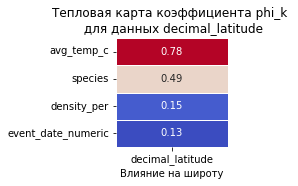

In [82]:
plt.figure(figsize=(2, 2))

correlation_matrix_heatmap = correlation_matrix.loc[correlation_matrix.index != 'decimal_latitude'][['decimal_latitude']].sort_values(by='decimal_latitude', ascending=False)
sns.heatmap(correlation_matrix_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

plt.title('Тепловая карта коэффициента phi_k \n для данных decimal_latitude')
plt.xlabel('Влияние на широту')

plt.show()

Анализ матрицы зависимостей для целевой переменной широты `decimal_latitude`, показал что главным доминирующим фактором выступает среднемесячная температура `avg_temp_c` - показавшая высокий уровень связи `phi_K = 0.78`. Это математически доказывает жесткую привязку популяции птиц к климатическим условиям и тепловому режиму территорий. Биологический вид `species` оказывает умеренное влияние `phi_K = 0.49`, что может свидетельствовать о различии в границах ареалов у разных видов лебедей. Временной фактор `event_date`  и фактор плотности населения `density_per` обладают слабой силой связи `phi_K = 0.13` и `phi_K = 0.15` соответственно. Фактор календарного времени сам по себе не определяет положение птицы. Таким образом, пространственное размещение популяции носит выраженный климатозависимый характер. Скорость смещения ареала сдерживается долгосрочными факторами — скоростью изменения растительности, формированием новых кормовых водоемов и консерватизмом гнездового поведения птиц.

Визуализируем связь между широтой и температурой:

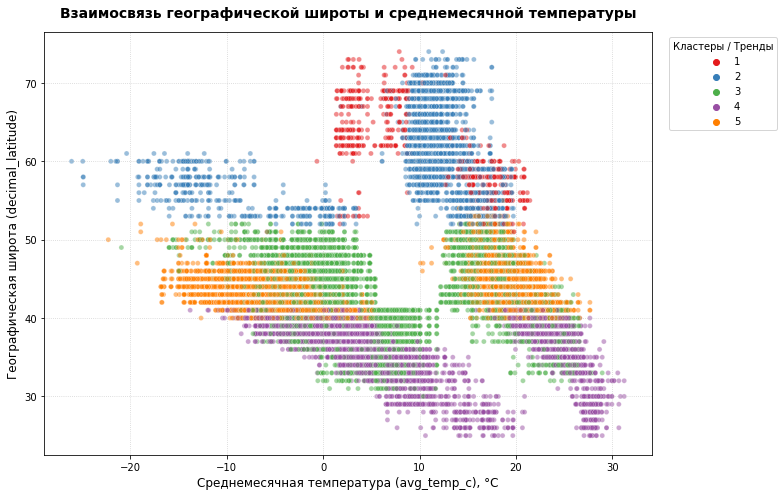

In [83]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=data_seasonal_enriched,
    x='avg_temp_c',
    y='decimal_latitude',
    hue='cluster',
    palette='Set1',      
    alpha=0.5,           
    s=25)

plt.title('Взаимосвязь географической широты и среднемесячной температуры', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Среднемесячная температура (avg_temp_c), °C', fontsize=12)
plt.ylabel('Географическая широта (decimal_latitude)', fontsize=12)

plt.legend(title='Кластеры / Тренды', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

Данные разделяются на два массивных потока в центре. Левое "крыло" показывает классическую сильную линейную связь: чем выше широта, тем ниже температура (уходит в глубокий минус до -25 °C). "Правое" крыло образует обособленную ветвь: при относительно высоких широтах (40–55) сохраняются довольно высокие температуры (15–25 °C). В географии это явный признак морского климата или влияния теплых течений (например, Западное побережье или Гольфстрим), где на севере значительно теплее, чем в глубине континента. 

Характеристика 5 выделенных кластеров:
  - Кластер 1 (Красный): Высокоширотный «северный» кластер (60–75 градусов широты), но с умеренной температурой (0...20 °C).
  - Кластер 2 (Синий): Находится на широтах 55–75 и в широком температурном диаразоне -20...20 °C.
  - Кластер 3 (Зеленый): Занимает диапазон температур -15...25 °C) на умеренных широтах (30–55). 
  - Кластер 4 (Фиолетовый): Самый "южный" кластер (широта 25–40) в температурном диаразоне -10...30 °C. 
  - Кластер 5 (Оранжевый): Умеренно-южный кластер (широта 40–50), сфокусирован в в температурном диаразоне -15...25 °C.

# Выводы

В работе были проанализированы данные о наблюдении за лебедями Global Biodiversity Information Facility. В ходе предабработки данных был сформирован датасет с информацией о наблюдениях за тремя видами лебедей: `Cygnus olor`, `Cygnus buccinator`, `Cygnus columbianus`, на территории США и Канады. Добавлены данные по плотности населения и температуре. Были выделены 5 временных периода (1980-1988, 1989-1997, 1998-2006, 2007-2015, 2016-2023). Итоговый датафрейм сохранен в data_seasonal_enriched.csv. 

Для анализа статистически значимого смещения ареала лебедей был применет метод Уорда и выделены 5 кластеров. Анализ линейной регрессии по кластерам показал, что в кластерах 1, 2, 4, 5 изменение широты по годам статистически значимо. При этом характер тренда неоднороден: в кластерах 1, 2, 4 наблюдается отрицательный сдвиг (на юг), в то время как в кластере 5 зафиксировано смещение севернее (Slope > 0). Это указывает на то, что динамика ареала лебедей зависит от локальных экосистемных факторов внутри конкретных климатических зон. В кластере 3 тренд изменения широты статистически незначим, что свидетельствует о стабильности географических границ популяции или о хаотичном характере миграций внутри данной конкретной зоны.

Была произведена оценка влияние внешних факторов (температура, плотность населения, дата события) на пространственное распределение птиц. Главным доминирующим фактором выступает среднемесячная температура - показавшая высокий уровень связи `phi_K = 0.78`. Влияние биологического вида `species` оценивается как умеренное `phi_K = 0.49`, а изолированный фактор времени `event_date` обладает слабой силой связи `phi_K = 0.13`. Также слабую связь показал  фактор плотности населения `density_per` `phi_K = 0.15`. Это доказывает, что смещение птиц на север носит выраженный климатозависимый характер: популяция реагирует не на календарный ход лет, а перемещается вслед за температурными изотермами.